In [1]:
""" 
Solar Demon - 2026 Grad Colloquium Learning Package
=====================================================
Description: This notebook will open Solar data files, and assess when solar dorught is occuring

Version History: 18/06/26 D.OB writing new script using hackathon code as a base.

Notes:

"""

' \nSolar Demon - 2026 Grad Colloquium Learning Package\n=====================================================\nDescription: This notebook will open Solar data files, and assess when solar dorught is occuring\n\nVersion History: 18/06/26 D.OB writing new script using hackathon code as a base.\n\nNotes:\n\n'

In [39]:
from pathlib import Path
import xarray as xr         # NetCDF & multi-dimensional data
import pandas as pd          # tabular/CSV data
import numpy as np           # numerical operations
import matplotlib.pyplot as plt  # plotting
from glob import glob        #global path directory
import geopandas as gdp
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
lulls_dur = pd.read_csv("/scratch/nf33/db5194/GC_26_Solar_Lull/data2/event_risk_by_duration_all_days.csv")

In [3]:
lulls_dur

,Unnamed: 0,time,Q5,T2,Q8,V5,V1,T3,S6,V2,...,N4,N3,GPER,ACTE,GBRI,GDAR,GHOB,GMEL,GADE,GSYD
0,0,2015-08-01,none,none,none,low,low,none,none,low,...,none,none,none,none,none,none,none,low,low,none
1,1,2015-08-02,none,low,none,none,none,none,none,none,...,none,none,none,low,none,none,none,none,none,none
2,2,2015-08-03,none,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
3,3,2015-08-04,none,low,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
4,4,2015-08-05,none,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3801,3801,2025-12-27,high,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
3802,3802,2025-12-28,high,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
3803,3803,2025-12-29,high,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
3804,3804,2025-12-30,high,low,none,none,none,low,none,none,...,none,none,none,none,none,none,none,none,none,none


In [10]:
regions = lulls_dur.columns.drop('time')

low_days = {}

for region in regions:
    low_days[region] = np.count_nonzero(lulls_dur[region] == 'low')

low_days = pd.DataFrame({
    'region': low_days.keys(),
    'low_days': low_days.values()
})
low_days

#low_days = pd.Series(low_days
 #                   )
#print(low_days.sort_values(ascending=False))

,region,low_days
0,Unnamed: 0,0
1,Q5,125
2,T2,428
3,Q8,199
4,V5,400
5,V1,307
6,T3,389
7,S6,183
8,V2,266
9,Q9,157


In [21]:
gdf = gdp.read_file("/scratch/nf33/ad1803/GC26_Solar_Lull/Training/Data/REZs/REZ_Map.shp")
gdf

,name,source_fil,geometry
0,Q1,shapefile_1,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -..."
1,Q2,shapefile_1,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -..."
2,Q3,shapefile_1,"POLYGON Z ((146.27782 -18.7192 0, 146.28263 -1..."
3,Q4,shapefile_1,"POLYGON Z ((147.64366 -19.94015 0, 147.68341 -..."
4,Q5,shapefile_1,"POLYGON Z ((145.82086 -23.84279 0, 145.7004 -2..."
5,Q6,shapefile_1,"POLYGON Z ((149.9586 -24.15382 0, 149.93313 -2..."
6,Q7,shapefile_1,"POLYGON Z ((152.2709 -25.06574 0, 152.277 -25...."
7,Q8,shapefile_1,"POLYGON Z ((150.85196 -26.29194 0, 151.08218 -..."
8,Q9,shapefile_1,"POLYGON Z ((149.13813 -23.31492 0, 149.33179 -..."
9,N1,shapefile_1,"POLYGON Z ((149.63862 -28.78058 0, 149.71236 -..."


In [22]:
gdf_merged = gdf.merge(low_days, left_on='name', right_on='region', how='left')
gdf_merged

,name,source_fil,geometry,region,low_days
0,Q1,shapefile_1,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",NaN,NaN
1,Q2,shapefile_1,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -...",Q2,80.0
2,Q3,shapefile_1,"POLYGON Z ((146.27782 -18.7192 0, 146.28263 -1...",Q3,159.0
3,Q4,shapefile_1,"POLYGON Z ((147.64366 -19.94015 0, 147.68341 -...",Q4,130.0
4,Q5,shapefile_1,"POLYGON Z ((145.82086 -23.84279 0, 145.7004 -2...",Q5,125.0
5,Q6,shapefile_1,"POLYGON Z ((149.9586 -24.15382 0, 149.93313 -2...",Q6,173.0
6,Q7,shapefile_1,"POLYGON Z ((152.2709 -25.06574 0, 152.277 -25....",Q7,216.0
7,Q8,shapefile_1,"POLYGON Z ((150.85196 -26.29194 0, 151.08218 -...",Q8,199.0
8,Q9,shapefile_1,"POLYGON Z ((149.13813 -23.31492 0, 149.33179 -...",Q9,157.0
9,N1,shapefile_1,"POLYGON Z ((149.63862 -28.78058 0, 149.71236 -...",N1,210.0


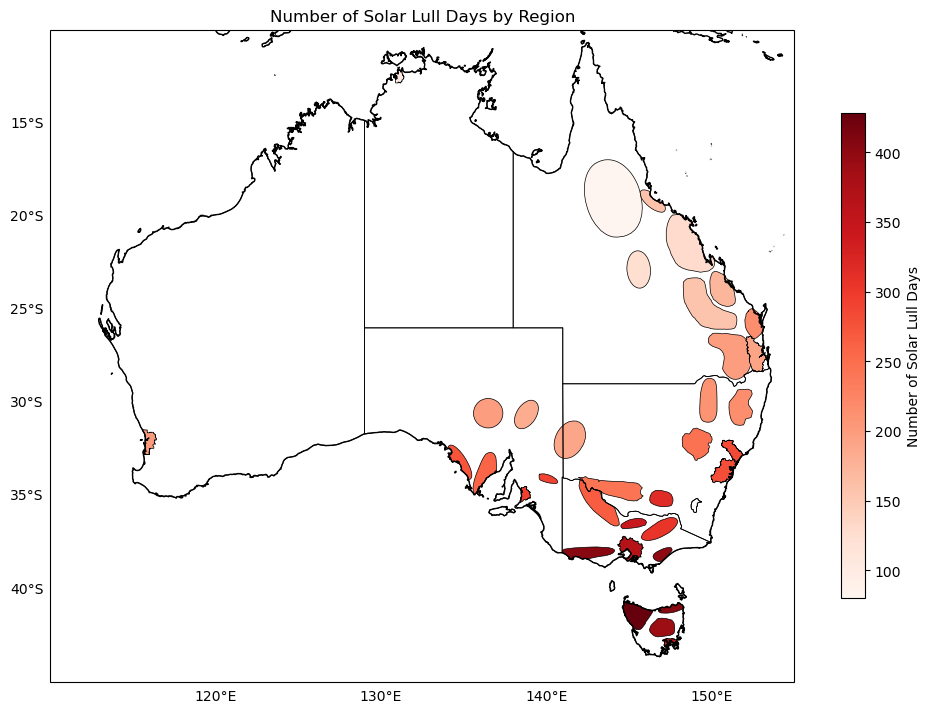

In [46]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())

gdf_merged.plot(column='low_days', cmap='Reds', linewidth=0.5, edgecolor='black', legend=False, ax=ax, transform=ccrs.PlateCarree())

ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

# Manual colorbar with controlled size
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=gdf_merged['low_days'].min(), vmax=gdf_merged['low_days'].max()))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05)
cbar.set_label('Number of Solar Lull Days')

ax.set_title('Number of Solar Lull Days by Region')
plt.tight_layout()
plt.show()

In [47]:
def risk(x,y):
    result = x+y
    return result


In [48]:
risk (4,3)

7